In [1]:
import pandas as pd

df = pd.read_csv('aice_preprocessing_practice.csv')
df.head()

,customer_id,age,gender,city,membership,signup_date,last_order_date,monthly_spend,visits,satisfaction,churn
0,C0001,28.0,Male,Incheon,Silver,2024-03-06,2026-04-05,41700.0,6,2.0,No
1,C0002,35.0,Female,Daegu,Gold,2024-05-11,2026-07-09,55400.0,11,3.0,No
2,C0003,42.0,Male,Seoul,Basic,2024-07-16,2026-02-13,69100.0,16,4.0,No
3,C0004,NaN,Female,Busan,Silver,2024-09-21,2026-05-17,82800.0,3,5.0,No
4,C0005,56.0,Male,Incheon,Gold,2024-11-26,2026-08-21,96500.0,8,1.0,Yes


In [2]:
df.shape

(46, 11)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      46 non-null     str    
 1   age              45 non-null     float64
 2   gender           46 non-null     str    
 3   city             45 non-null     str    
 4   membership       45 non-null     str    
 5   signup_date      46 non-null     str    
 6   last_order_date  45 non-null     str    
 7   monthly_spend    45 non-null     float64
 8   visits           46 non-null     int64  
 9   satisfaction     45 non-null     float64
 10  churn            46 non-null     str    
dtypes: float64(3), int64(1), str(7)
memory usage: 4.1 KB


In [4]:
df.isnull().sum()

customer_id        0
age                1
gender             0
city               1
membership         1
signup_date        0
last_order_date    1
monthly_spend      1
visits             0
satisfaction       1
churn              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(2)

In [6]:
# 모든 컬럼값과 아이디까지 동일해서 단순 중복으로 보고 제거해도 됨
df[df.duplicated(keep=False)].sort_values('customer_id')

,customer_id,age,gender,city,membership,signup_date,last_order_date,monthly_spend,visits,satisfaction,churn
5,C0006,24.0,Female,Daegu,Basic,2024-01-04,2026-03-25,110200.0,13,2.0,No
44,C0006,24.0,Female,Daegu,Basic,2024-01-04,2026-03-25,110200.0,13,2.0,No
17,C0018,30.0,Female,Daegu,Basic,2024-01-10,2026-07-19,84600.0,1,4.0,No
45,C0018,30.0,Female,Daegu,Basic,2024-01-10,2026-07-19,84600.0,1,4.0,No


In [7]:
# drop_duplicates
df = df.drop_duplicates()
df.shape

(44, 11)

In [8]:
df.describe()

,age,monthly_spend,visits,satisfaction
count,43.000000,43.000000,44.000000,43.000000
mean,41.418605,144165.116279,9.590909,3.046512
std,13.734268,169935.512816,5.226579,1.430176
min,21.000000,6500.000000,1.000000,1.000000
25%,30.500000,59900.000000,5.000000,2.000000
50%,41.000000,112000.000000,9.500000,3.000000
75%,50.500000,167700.000000,14.000000,4.000000
max,92.000000,980000.000000,18.000000,5.000000


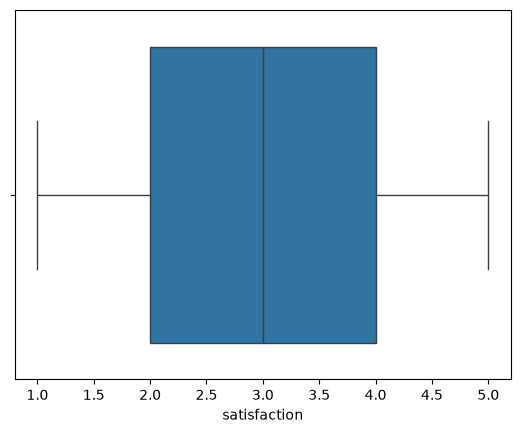

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='satisfaction')
plt.show()

In [10]:
df['age'] = df['age'].fillna(df['age'].median())
df['monthly_spend'] = df['monthly_spend'].fillna(df['monthly_spend'].median())
df['satisfaction'] = df['satisfaction'].fillna(df['satisfaction'].mode()[0])
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['membership'] = df['membership'].fillna(df['membership'].mode()[0])

In [11]:
df.isnull().sum()

customer_id        0
age                0
gender             0
city               0
membership         0
signup_date        0
last_order_date    1
monthly_spend      0
visits             0
satisfaction       0
churn              0
dtype: int64

In [12]:
# 날짜형 변환
# errors='coerce' -> 날짜 결측치 NaT
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_order_date'] = pd.to_datetime(df['last_order_date'], errors='coerce')

# 새 날짜 컬럼 생성
df['customer_period'] = (df['last_order_date']-df['signup_date']).dt.days

# 생성된 컬럼 결측치 제거
df['customer_period'] = df['customer_period'].fillna(df['customer_period'].median())

# signup_date의 월만 뽑기
df['signup_month'] = df['signup_date'].dt.month

# 안쓰는 컬럼 삭제
df = df.drop(columns=['signup_date', 'last_order_date'])

In [13]:
df.head()

,customer_id,age,gender,city,membership,monthly_spend,visits,satisfaction,churn,customer_period,signup_month
0,C0001,28.0,Male,Incheon,Silver,41700.0,6,2.0,No,760.0,3
1,C0002,35.0,Female,Daegu,Gold,55400.0,11,3.0,No,789.0,5
2,C0003,42.0,Male,Seoul,Basic,69100.0,16,4.0,No,577.0,7
3,C0004,41.0,Female,Busan,Silver,82800.0,3,5.0,No,603.0,9
4,C0005,56.0,Male,Incheon,Gold,96500.0,8,1.0,Yes,633.0,11


In [14]:
df.dtypes

customer_id            str
age                float64
gender                 str
city                   str
membership             str
monthly_spend      float64
visits               int64
satisfaction       float64
churn                  str
customer_period    float64
signup_month         int32
dtype: object

In [15]:
df.isnull().sum()

customer_id        0
age                0
gender             0
city               0
membership         0
monthly_spend      0
visits             0
satisfaction       0
churn              0
customer_period    0
signup_month       0
dtype: int64

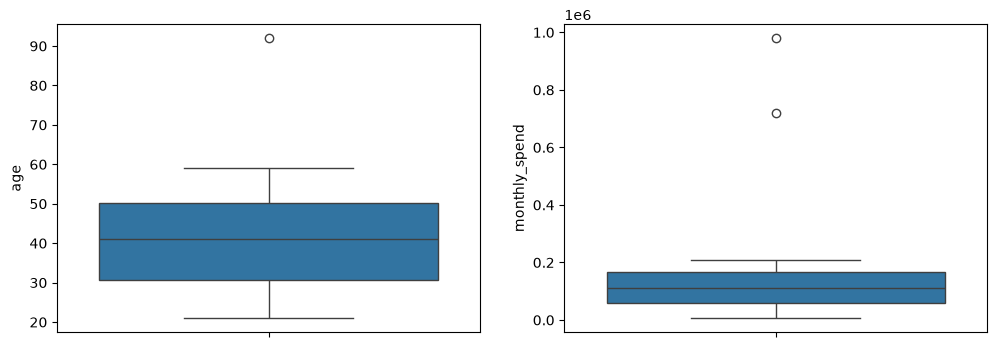

In [16]:
# 그래프 여러개 배치 / 전체(1행 2열)/개별 그래프 칸
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df, y='age', ax=axes[0])
sns.boxplot(data=df, y='monthly_spend', ax=axes[1])

plt.show()

In [17]:
df.head()

,customer_id,age,gender,city,membership,monthly_spend,visits,satisfaction,churn,customer_period,signup_month
0,C0001,28.0,Male,Incheon,Silver,41700.0,6,2.0,No,760.0,3
1,C0002,35.0,Female,Daegu,Gold,55400.0,11,3.0,No,789.0,5
2,C0003,42.0,Male,Seoul,Basic,69100.0,16,4.0,No,577.0,7
3,C0004,41.0,Female,Busan,Silver,82800.0,3,5.0,No,603.0,9
4,C0005,56.0,Male,Incheon,Gold,96500.0,8,1.0,Yes,633.0,11


In [18]:

print(df['gender'].value_counts())
print(df['churn'].value_counts())
print(df['city'].value_counts())
print(df['membership'].value_counts())

df['churn'] = df['churn'].map({'No':0,'Yes':1})
df['gender'] = df['gender'].map({'Male':0,'Female':1})

df = pd.get_dummies(df, columns=['city', 'membership'], dtype=int)

gender
Male      22
Female    22
Name: count, dtype: int64
churn
No     32
Yes    12
Name: count, dtype: int64
city
Busan      12
Incheon    11
Daegu      11
Seoul      10
Name: count, dtype: int64
membership
Gold      16
Silver    15
Basic     13
Name: count, dtype: int64


In [19]:
df.head()

,customer_id,age,gender,monthly_spend,visits,satisfaction,churn,customer_period,signup_month,city_Busan,city_Daegu,city_Incheon,city_Seoul,membership_Basic,membership_Gold,membership_Silver
0,C0001,28.0,0,41700.0,6,2.0,0,760.0,3,0,0,1,0,0,0,1
1,C0002,35.0,1,55400.0,11,3.0,0,789.0,5,0,1,0,0,0,1,0
2,C0003,42.0,0,69100.0,16,4.0,0,577.0,7,0,0,0,1,1,0,0
3,C0004,41.0,1,82800.0,3,5.0,0,603.0,9,1,0,0,0,0,0,1
4,C0005,56.0,0,96500.0,8,1.0,1,633.0,11,0,0,1,0,0,1,0


In [20]:
df.dtypes

customer_id              str
age                  float64
gender                 int64
monthly_spend        float64
visits                 int64
satisfaction         float64
churn                  int64
customer_period      float64
signup_month           int32
city_Busan             int64
city_Daegu             int64
city_Incheon           int64
city_Seoul             int64
membership_Basic       int64
membership_Gold        int64
membership_Silver      int64
dtype: object

In [21]:
df.isnull().sum()

customer_id          0
age                  0
gender               0
monthly_spend        0
visits               0
satisfaction         0
churn                0
customer_period      0
signup_month         0
city_Busan           0
city_Daegu           0
city_Incheon         0
city_Seoul           0
membership_Basic     0
membership_Gold      0
membership_Silver    0
dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

# x/y 분리
x = df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)



In [23]:
# 스케일링
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler()

x_train_scaled = scaled.fit_transform(x_train)
x_test_scaled = scaled.transform(x_test)

ValueError: could not convert string to float: 'C0022'

In [ ]:
# 로지스틱 회귀 모델 사용
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled)

In [ ]:
print('실제값 : ', y_test.values)
print('예측값 : ', pred)

실제값 :  [0 0 1 0 0 0 0 1 0]
예측값 :  [0 0 1 0 0 0 0 1 0]


In [ ]:
# 혼동행렬, 평가지표, accuracy
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print(accuracy_score(y_test, pred))

[[7 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         2

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9

1.0


In [ ]:
# 딥러닝 진입 - Dense 신경망 만들기 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)